# CFUR-V2 — Budgeted Counterfactual Multimodal Escalation

This notebook is the V2 revision of the previous CFUR experiment.

## What changed from V1

**V1 finding:** the pilot showed that the utility router did not beat a simple uncertainty router, while the expensive branch was not better than the cheap branch. Therefore V2 does **not** assume that the proposed router works.

V2 tests the stronger scientific question:

> **At the same additional-compute budget, can a counterfactual utility-per-cost router select samples that benefit more from expensive multimodal reasoning than confidence-only, modality-disagreement, and random routing?**

### Main changes

1. **Budget sweep:** 0%, 2.5%, 5%, 10%, 20%, 30%, 50%, 75%, 100% deep execution.
2. **Utility-per-cost target:**

   `utility_per_cost = (cheap CE - deep CE) / extra_deep_cost`
3. **Matched-cost baselines:** uncertainty, modality disagreement, and random routing.
4. **Text-only and image-only heads:** used for a modality-disagreement routing baseline.
5. **Residual deep head:** predicts a correction to the cheap CLIP decision instead of replacing it blindly.
6. **Validation-only budget selection:** the test set is never used to choose thresholds.
7. **Multiple seeds:** configurable 3-seed pilot or 5-seed manuscript mode.
8. **Statistical analysis:** paired bootstrap CIs over test predictions.
9. **Resource profiling:** measured CLIP cost, deep cost, routed cost, latency, throughput and peak VRAM.
10. **Two Fakeddit tasks:** binary (`2_way_label`) and fine-grained (`6_way_label`) can be run by changing one setting.

### Important
The notebook is deliberately falsifiable. It will report if CFUR fails to beat the matched-cost baselines.

In [49]:
# Kaggle dependency setup
# Internet must be enabled for the first model download.
#
# Pillow ships quarterly and has twice broken this exact import chain:
#   ImportError: cannot import name '_Ink' from 'PIL._typing'
# 12.0.0/12.1.0 shipped the bug outright; 12.2.0 fixed it; 12.3.0 (2026-07-01)
# reworked ImageText/ImageFont interop and appears to have reintroduced it.
# Pin to the known-good window instead of an open-ended ">=".
#
# pip installing a newer Pillow inside a cell does not retroactively fix a
# module that's already loaded in the running kernel, so this cell installs
# once, then force-restarts the kernel so the next pass actually picks it up.
import os

_FLAG = "/kaggle/working/.cfur_v2_deps_installed"

if not os.path.exists(_FLAG):
    get_ipython().system('pip -q install -U "transformers>=5.0,<6" accelerate safetensors scikit-learn pandas "pillow>=12.2.0,<12.3.0" tqdm psutil requests')
    with open(_FLAG, "w") as f:
        f.write("ok")
    print("Dependencies installed with a safe Pillow pin. Restarting the kernel now \u2014 "
          "re-run this cell (or Run All) once more to continue.")
    os.kill(os.getpid(), 9)
else:
    print("Dependencies already installed in this session \u2014 continuing.")


Dependencies already installed in this session — continuing.


In [50]:
import os, gc, time, math, random, warnings, json, subprocess, sys
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import pandas as pd
from PIL import Image, ImageFile

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset

from transformers import CLIPModel, CLIPProcessor, ViltModel, ViltProcessor

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    log_loss, roc_auc_score, confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
ImageFile.LOAD_TRUNCATED_IMAGES = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [51]:
# ============================================================
# V2 CONFIGURATION
# ============================================================

RUN_MODE = "PILOT"       # "PILOT" or "PAPER"
TASKS_TO_RUN = ["binary"]  # ["binary"] or ["binary", "six_way"]

if RUN_MODE == "PAPER":
    SEEDS = [13, 37, 71, 101, 202]
    MAX_TRAIN, MAX_VAL, MAX_TEST = None, None, None
else:
    SEEDS = [13]
    MAX_TRAIN, MAX_VAL, MAX_TEST = 12000, 2000, 2000

# Change to "6_way_label" for the fine-grained task.
FAKEDDIT_LABEL_COL = "2_way_label"

MANIFEST_CSV = ""

TEXT_COL_CANDIDATES = ["clean_title", "title", "text"]
ID_COL_CANDIDATES = ["id", "submission_id"]
FAKEDDIT_IMAGE_URL_CANDIDATES = ["image_url", "img_url"]

CLIP_NAME = "openai/clip-vit-base-patch32"
VILT_NAME = "dandelin/vilt-b32-mlm"

BATCH_CLIP = 32
BATCH_VILT = 16
HEAD_BATCH = 512

HEAD_EPOCHS = 20 if RUN_MODE == "PAPER" else 12
ROUTER_EPOCHS = 25 if RUN_MODE == "PAPER" else 12
PATIENCE = 4

LR_HEAD = 1e-3
LR_ROUTER = 8e-4
WEIGHT_DECAY = 1e-4

# Keep classifier training and router target estimation separated.
ROUTER_HOLDOUT = 0.20

# The core contribution is evaluated at all these budgets.
BUDGETS = [0.00, 0.025, 0.05, 0.10, 0.20, 0.30, 0.50, 0.75, 1.00]

N_BOOT = 1000 if RUN_MODE == "PAPER" else 300

ALLOW_IMAGE_URL_FALLBACK = True
IMAGE_DOWNLOAD_WORKERS = 24
IMAGE_DOWNLOAD_TIMEOUT = 8
IMAGE_DOWNLOAD_DIRNAME = "fakeddit_images_v2"

OUT_DIR = Path("/kaggle/working/cfur_v2_outputs")
CACHE_DIR = Path("/kaggle/working/cfur_v2_cache")
OUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

seed_everything(SEEDS[0])
print("RUN_MODE:", RUN_MODE)
print("Seeds:", SEEDS)
print("Task:", FAKEDDIT_LABEL_COL)
print("Budgets:", BUDGETS)

RUN_MODE: PILOT
Seeds: [13]
Task: 2_way_label
Budgets: [0.0, 0.025, 0.05, 0.1, 0.2, 0.3, 0.5, 0.75, 1.0]


## Data loading

The previous Kaggle run had no local image files and recovered only the rows whose historical image URLs were still reachable. V2 keeps that behavior but makes the availability statistics explicit.

For a manuscript run, **prefer a Kaggle dataset containing local Fakeddit images** and set `MANIFEST_CSV` to a manifest with:

`text,image_path,label,split`

That avoids URL survivorship bias.

In [52]:
def first_existing_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise ValueError(
        f"None of {candidates} found. Available columns: {list(df.columns)[:50]}"
    )

def build_image_index(root="/kaggle/input"):
    exts = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}
    index = {}
    for p in tqdm(Path(root).rglob("*"), desc="indexing local images"):
        if p.is_file() and p.suffix.lower() in exts:
            index.setdefault(p.stem, str(p))
    print("Local images indexed:", len(index))
    return index

def pick_fakeddit_files():
    files = list(Path("/kaggle/input").rglob("*.tsv"))
    def choose(words):
        cands = []
        for p in files:
            s = p.name.lower()
            if "multimodal" in s and any(w in s for w in words):
                cands.append(p)
        return sorted(cands, key=lambda x: len(str(x)))[0] if cands else None
    return (
        choose(["train"]),
        choose(["validate", "validation", "val"]),
        choose(["test_public", "test"])
    )

def stratified_cap(df, n, label_col, seed):
    if n is None or len(df) <= n:
        return df.reset_index(drop=True)
    try:
        _, sampled = train_test_split(
            df, test_size=n, stratify=df[label_col], random_state=seed
        )
        return sampled.reset_index(drop=True)
    except Exception:
        return df.sample(n=n, random_state=seed).reset_index(drop=True)

def download_images_from_urls(
    df, url_col, id_col, out_dir,
    workers=24, timeout=8
):
    import requests
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    def fetch(sid, url):
        sid = str(sid)
        if not isinstance(url, str) or not url.startswith("http"):
            return sid, None
        dest = out_dir / f"{sid}.jpg"
        if dest.exists() and dest.stat().st_size > 0:
            return sid, str(dest)
        try:
            r = requests.get(
                url,
                timeout=timeout,
                headers={"User-Agent": "Mozilla/5.0"}
            )
            if r.status_code == 200 and r.content:
                with open(dest, "wb") as f:
                    f.write(r.content)
                return sid, str(dest)
        except Exception:
            pass
        return sid, None

    pairs = list(zip(df[id_col].astype(str), df[url_col]))
    result = {}
    with ThreadPoolExecutor(max_workers=workers) as ex:
        futures = [ex.submit(fetch, sid, url) for sid, url in pairs]
        for fut in tqdm(
            as_completed(futures),
            total=len(futures),
            desc="downloading images"
        ):
            sid, path = fut.result()
            if path:
                result[sid] = path
    return result

def standardize_fakeddit(df, split_name, image_index):
    text_col = first_existing_col(df, TEXT_COL_CANDIDATES)
    id_col = first_existing_col(df, ID_COL_CANDIDATES)
    if FAKEDDIT_LABEL_COL not in df.columns:
        raise ValueError(
            f"{FAKEDDIT_LABEL_COL} not found. "
            f"Label columns: {[c for c in df.columns if 'label' in c.lower()]}"
        )
    out = pd.DataFrame({
        "text": df[text_col].fillna("").astype(str),
        "sample_id": df[id_col].astype(str),
        "label": df[FAKEDDIT_LABEL_COL],
        "split": split_name
    })
    out["image_path"] = out["sample_id"].map(image_index)
    before = len(out)
    out = out.dropna(subset=["image_path", "label"])
    out = out[out["text"].str.len() > 0].reset_index(drop=True)
    print(f"{split_name}: {len(out)}/{before} rows have usable text+image")
    return out[["text", "image_path", "label", "split", "sample_id"]]

def load_manifest():
    if MANIFEST_CSV:
        m = pd.read_csv(MANIFEST_CSV)
        required = {"text", "image_path", "label", "split"}
        missing = required - set(m.columns)
        if missing:
            raise ValueError(f"Manifest missing columns: {missing}")
        return m

    train_p, val_p, test_p = pick_fakeddit_files()
    print("Detected:", train_p, val_p, test_p)
    if not all([train_p, val_p, test_p]):
        raise FileNotFoundError(
            "Could not find Fakeddit multimodal TSVs. "
            "Attach the Fakeddit dataset or set MANIFEST_CSV."
        )

    raw = {
        "train": pd.read_csv(train_p, sep="\t"),
        "val": pd.read_csv(val_p, sep="\t"),
        "test": pd.read_csv(test_p, sep="\t")
    }

    image_index = build_image_index("/kaggle/input")

    if len(image_index) == 0 and ALLOW_IMAGE_URL_FALLBACK:
        print("No local images found. Downloading only bounded pilot/full-mode rows.")
        url_col = first_existing_col(raw["train"], FAKEDDIT_IMAGE_URL_CANDIDATES)
        id_col = first_existing_col(raw["train"], ID_COL_CANDIDATES)

        caps = {
            "train": MAX_TRAIN,
            "val": MAX_VAL,
            "test": MAX_TEST
        }

        for split in ["train", "val", "test"]:
            cap = caps[split]
            if cap is None:
                cap = 50000
            # Oversample candidates to compensate for dead historical URLs.
            candidate_n = min(
                len(raw[split]),
                int(cap * 1.5) if cap else len(raw[split])
            )
            raw[split] = stratified_cap(
                raw[split], candidate_n, FAKEDDIT_LABEL_COL, SEEDS[0]
            )

        download_dir = CACHE_DIR / IMAGE_DOWNLOAD_DIRNAME
        image_index = {}
        for split in ["train", "val", "test"]:
            got = download_images_from_urls(
                raw[split],
                url_col,
                id_col,
                download_dir,
                workers=IMAGE_DOWNLOAD_WORKERS,
                timeout=IMAGE_DOWNLOAD_TIMEOUT
            )
            image_index.update(got)

        print("Total downloaded/cached images:", len(image_index))

    return pd.concat([
        standardize_fakeddit(raw["train"], "train", image_index),
        standardize_fakeddit(raw["val"], "val", image_index),
        standardize_fakeddit(raw["test"], "test", image_index)
    ], ignore_index=True)

manifest = load_manifest()
print("Rows after availability filtering:", len(manifest))
display(manifest.groupby("split").size().rename("available_rows").to_frame())

Detected: /kaggle/input/datasets/vanshikavmittal/fakeddit-dataset/multimodal_only_samples/multimodal_train.tsv /kaggle/input/datasets/vanshikavmittal/fakeddit-dataset/multimodal_only_samples/multimodal_validate.tsv /kaggle/input/datasets/vanshikavmittal/fakeddit-dataset/multimodal_only_samples/multimodal_test_public.tsv


indexing local images: 0it [00:00, ?it/s]

Local images indexed: 0
No local images found. Downloading only bounded pilot/full-mode rows.


downloading images:   0%|          | 0/18000 [00:00<?, ?it/s]

downloading images:   0%|          | 0/3000 [00:00<?, ?it/s]

downloading images:   0%|          | 0/3000 [00:00<?, ?it/s]

Total downloaded/cached images: 22724
train: 17021/18000 rows have usable text+image
val: 2857/3000 rows have usable text+image
test: 2846/3000 rows have usable text+image
Rows after availability filtering: 22724


,available_rows
split,
test,2846
train,17021
val,2857


In [53]:
le = LabelEncoder()
manifest["label_raw"] = manifest["label"]
manifest["label"] = le.fit_transform(manifest["label"].astype(str))
NUM_CLASSES = len(le.classes_)

train_df = stratified_cap(
    manifest[manifest.split=="train"].copy(),
    MAX_TRAIN, "label", SEEDS[0]
)
val_df = stratified_cap(
    manifest[manifest.split=="val"].copy(),
    MAX_VAL, "label", SEEDS[0]
)
test_df = stratified_cap(
    manifest[manifest.split=="test"].copy(),
    MAX_TEST, "label", SEEDS[0]
)

print("Classes:", dict(enumerate(le.classes_)))
print("Train/Val/Test:", len(train_df), len(val_df), len(test_df))
print("Train class distribution:")
display(train_df["label"].value_counts(normalize=True).sort_index())

Classes: {0: '0', 1: '1'}
Train/Val/Test: 12000 2000 2000
Train class distribution:


label
0    0.617667
1    0.382333
Name: proportion, dtype: float64

In [54]:
class RawMultimodalDataset(Dataset):
    def __init__(self, frame):
        self.df = frame.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        row = self.df.iloc[i]
        try:
            img = Image.open(row.image_path).convert("RGB")
            w, h = img.size
            if w < 2 or h < 2 or max(w,h)/max(min(w,h),1) > 20:
                img = Image.new("RGB", (224,224), "white")
        except Exception:
            img = Image.new("RGB", (224,224), "white")
        return {
            "text": str(row.text),
            "image": img,
            "label": int(row.label),
            "row_id": i
        }

def raw_collate(batch):
    return {
        "texts": [x["text"] for x in batch],
        "images": [x["image"] for x in batch],
        "labels": torch.tensor([x["label"] for x in batch], dtype=torch.long),
        "row_ids": np.array([x["row_id"] for x in batch], dtype=np.int64)
    }

datasets = {
    "train": RawMultimodalDataset(train_df),
    "val": RawMultimodalDataset(val_df),
    "test": RawMultimodalDataset(test_df)
}

## Frozen encoders

The backbones remain frozen for feasibility and to make the routing contribution identifiable.

In [55]:
clip_processor = CLIPProcessor.from_pretrained(CLIP_NAME)
clip_model = CLIPModel.from_pretrained(CLIP_NAME).to(DEVICE).eval()
for p in clip_model.parameters():
    p.requires_grad = False

vilt_processor = ViltProcessor.from_pretrained(VILT_NAME)
vilt_model = ViltModel.from_pretrained(VILT_NAME).to(DEVICE).eval()
for p in vilt_model.parameters():
    p.requires_grad = False

CLIP_DIM = clip_model.config.projection_dim
VILT_DIM = vilt_model.config.hidden_size
print("CLIP_DIM =", CLIP_DIM, "VILT_DIM =", VILT_DIM)

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/206 [00:00<?, ?it/s]

[transformers] ViltModel LOAD REPORT from: dandelin/vilt-b32-mlm
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
mlm_score.decoder.weight             | UNEXPECTED |  | 
mlm_score.transform.LayerNorm.weight | UNEXPECTED |  | 
mlm_score.bias                       | UNEXPECTED |  | 
mlm_score.transform.dense.weight     | UNEXPECTED |  | 
mlm_score.transform.dense.bias       | UNEXPECTED |  | 
mlm_score.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CLIP_DIM = 512 VILT_DIM = 768


In [56]:
def cuda_sync():
    if torch.cuda.is_available():
        torch.cuda.synchronize()

def cache_ok(cache, n):
    if not cache.exists():
        return None
    z = np.load(cache)
    out = {k: z[k] for k in z.files}
    if len(out.get("row_id", [])) != n:
        print("Ignoring stale cache:", cache.name)
        return None
    return out

def extract_clip(ds, split):
    cache = CACHE_DIR / f"{split}_clip.npz"
    old = cache_ok(cache, len(ds))
    if old is not None:
        return old

    loader = DataLoader(
        ds, batch_size=BATCH_CLIP, shuffle=False,
        collate_fn=raw_collate, num_workers=0,
        pin_memory=torch.cuda.is_available()
    )
    T,V,Y,IDS = [],[],[],[]
    cuda_sync(); t0=time.perf_counter()
    if torch.cuda.is_available(): torch.cuda.reset_peak_memory_stats()

    with torch.inference_mode():
        for b in tqdm(loader, desc=f"CLIP {split}"):
            proc = clip_processor(
                text=b["texts"], images=b["images"],
                return_tensors="pt", padding=True,
                truncation=True, max_length=77
            )
            proc = {k:v.to(DEVICE) for k,v in proc.items()}
            with torch.autocast(
                device_type="cuda", dtype=torch.float16,
                enabled=torch.cuda.is_available()
            ):
                te = clip_model.get_text_features(
                    input_ids=proc["input_ids"],
                    attention_mask=proc.get("attention_mask")
                )
                ie = clip_model.get_image_features(
                    pixel_values=proc["pixel_values"]
                )
            te = te.pooler_output if hasattr(te,"pooler_output") else te
            ie = ie.pooler_output if hasattr(ie,"pooler_output") else ie
            T.append(F.normalize(te.float(),dim=-1).cpu().numpy())
            V.append(F.normalize(ie.float(),dim=-1).cpu().numpy())
            Y.append(b["labels"].numpy())
            IDS.append(b["row_ids"])

    cuda_sync()
    sec=time.perf_counter()-t0
    peak=torch.cuda.max_memory_allocated()/1024**2 if torch.cuda.is_available() else np.nan
    out={
        "text":np.concatenate(T),
        "image":np.concatenate(V),
        "y":np.concatenate(Y),
        "row_id":np.concatenate(IDS),
        "seconds":np.array([sec]),
        "peak_mb":np.array([peak])
    }
    np.savez_compressed(cache,**out)
    return out

def extract_vilt(ds, split):
    cache = CACHE_DIR / f"{split}_vilt.npz"
    old = cache_ok(cache, len(ds))
    if old is not None:
        return old

    loader = DataLoader(
        ds, batch_size=BATCH_VILT, shuffle=False,
        collate_fn=raw_collate, num_workers=0,
        pin_memory=torch.cuda.is_available()
    )
    J,Y,IDS=[],[],[]
    cuda_sync(); t0=time.perf_counter()
    if torch.cuda.is_available(): torch.cuda.reset_peak_memory_stats()

    with torch.inference_mode():
        for b in tqdm(loader, desc=f"ViLT {split}"):
            proc=vilt_processor(
                images=b["images"], text=b["texts"],
                return_tensors="pt", padding=True,
                truncation=True, max_length=40
            )
            proc={k:v.to(DEVICE) for k,v in proc.items()}
            with torch.autocast(
                device_type="cuda", dtype=torch.float16,
                enabled=torch.cuda.is_available()
            ):
                out=vilt_model(**proc)
                joint=(
                    out.pooler_output
                    if getattr(out,"pooler_output",None) is not None
                    else out.last_hidden_state[:,0]
                )
            J.append(joint.float().cpu().numpy())
            Y.append(b["labels"].numpy())
            IDS.append(b["row_ids"])

    cuda_sync()
    sec=time.perf_counter()-t0
    peak=torch.cuda.max_memory_allocated()/1024**2 if torch.cuda.is_available() else np.nan
    out={
        "joint":np.concatenate(J),
        "y":np.concatenate(Y),
        "row_id":np.concatenate(IDS),
        "seconds":np.array([sec]),
        "peak_mb":np.array([peak])
    }
    np.savez_compressed(cache,**out)
    return out

features={}
for split in ["train","val","test"]:
    features[(split,"clip")]=extract_clip(datasets[split],split)
    features[(split,"vilt")]=extract_vilt(datasets[split],split)

resource_rows=[]
for split in ["train","val","test"]:
    n=len(datasets[split])
    for comp,key in [("CLIP","clip"),("ViLT","vilt")]:
        f=features[(split,key)]
        resource_rows.append({
            "split":split,
            "component":comp,
            "n":n,
            "seconds":float(f["seconds"][0]),
            "ms_per_sample":1000*float(f["seconds"][0])/n,
            "peak_vram_mb":float(f["peak_mb"][0])
        })
resource_components=pd.DataFrame(resource_rows)
display(resource_components)
resource_components.to_csv(OUT_DIR/"resource_components.csv",index=False)

,split,component,n,seconds,ms_per_sample,peak_vram_mb
0,train,CLIP,12000,134.924808,11.243734,1081.951172
1,train,ViLT,12000,244.654935,20.387911,1345.259277
2,val,CLIP,2000,21.113254,10.556627,1081.951172
3,val,ViLT,2000,40.798222,20.399111,1344.373535
4,test,CLIP,2000,19.363923,9.681962,1081.952148
5,test,ViLT,2000,38.541712,19.270856,1337.431152


## V2 heads

The expensive model is now a **residual deep head**:

`deep_logits = cheap_logits + learned correction(ViLT, text, image, cheap prediction)`

This asks the deep branch to spend its capacity on correcting the cheap decision rather than relearning the entire classifier from scratch.

Text-only and image-only heads provide the modality-disagreement baseline.

In [57]:
def cheap_features(t,v):
    cos=(t*v).sum(1,keepdims=True)
    return np.concatenate([t,v,np.abs(t-v),t*v,cos],1).astype("float32")

def modality_features(x):
    return np.asarray(x,dtype="float32")

def torchify(x):
    return torch.as_tensor(x,dtype=torch.float32)

class MLPHead(nn.Module):
    def __init__(self,in_dim,n_classes,hidden=256):
        super().__init__()
        self.net=nn.Sequential(
            nn.Linear(in_dim,hidden),
            nn.LayerNorm(hidden),
            nn.GELU(),
            nn.Dropout(.20),
            nn.Linear(hidden,128),
            nn.GELU(),
            nn.Dropout(.15),
            nn.Linear(128,n_classes)
        )
    def forward(self,x): return self.net(x)

class DeepResidualHead(nn.Module):
    def __init__(self,clip_dim,vilt_dim,n_classes,d=256):
        super().__init__()
        self.pt=nn.Linear(clip_dim,d)
        self.pv=nn.Linear(clip_dim,d)
        self.pj=nn.Linear(vilt_dim,d)
        self.fuse=nn.Sequential(
            nn.Linear(d*5+n_classes,512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(.25),
            nn.Linear(128 if False else 512,n_classes)
        )
    def forward(self,t,v,j,cheap_logits):
        t1=self.pt(t)
        v1=self.pv(v)
        j1=self.pj(j)
        z=torch.cat(
            [t1,v1,j1,torch.abs(t1-v1),t1*v1,cheap_logits],
            dim=1
        )
        # input is 5*d + n_classes
        return cheap_logits + self.fuse(z)

class UtilityRouter(nn.Module):
    def __init__(self,in_dim):
        super().__init__()
        self.net=nn.Sequential(
            nn.Linear(in_dim,256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(.20),
            nn.Linear(256,64),
            nn.GELU(),
            nn.Linear(64,1)
        )
    def forward(self,x): return self.net(x).squeeze(-1)

In [58]:
def class_weights(y):
    classes=np.arange(NUM_CLASSES)
    try:
        w=compute_class_weight("balanced",classes=classes,y=y)
    except Exception:
        w=np.ones(NUM_CLASSES)
    return torch.tensor(w,dtype=torch.float32,device=DEVICE)

def predict_head(model,X,batch=2048):
    model.eval(); out=[]
    with torch.inference_mode():
        for i in range(0,len(X),batch):
            out.append(model(torchify(X[i:i+batch]).to(DEVICE)).cpu().numpy())
    return np.concatenate(out)

def train_mlp(model,Xtr,ytr,Xv,yv,seed):
    seed_everything(seed)
    model.to(DEVICE)
    opt=torch.optim.AdamW(model.parameters(),lr=LR_HEAD,weight_decay=WEIGHT_DECAY)
    crit=nn.CrossEntropyLoss(weight=class_weights(ytr))
    loader=DataLoader(
        TensorDataset(torchify(Xtr),torch.tensor(ytr,dtype=torch.long)),
        batch_size=HEAD_BATCH,shuffle=True
    )
    best=-1; state=None; wait=0
    for ep in range(HEAD_EPOCHS):
        model.train()
        for xb,yb in loader:
            xb,yb=xb.to(DEVICE),yb.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            loss=crit(model(xb),yb)
            loss.backward(); opt.step()
        pred=predict_head(model,Xv).argmax(1)
        score=f1_score(yv,pred,average="macro")
        if score>best+1e-5:
            best=score; wait=0
            state={k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
        else:
            wait+=1
            if wait>=PATIENCE: break
    model.load_state_dict(state)
    return model

def train_regressor(model,Xtr,ytr,Xv,yv,seed):
    # Dedicated trainer for scalar-regression heads (e.g. UtilityRouter),
    # as distinct from train_mlp above which is classification-only
    # (CrossEntropyLoss + long class labels + F1-based early stopping).
    # Uses LR_ROUTER/ROUTER_EPOCHS, which the config already defines
    # separately from LR_HEAD/HEAD_EPOCHS for exactly this purpose.
    seed_everything(seed)
    model.to(DEVICE)
    opt=torch.optim.AdamW(model.parameters(),lr=LR_ROUTER,weight_decay=WEIGHT_DECAY)
    crit=nn.MSELoss()
    loader=DataLoader(
        TensorDataset(torchify(Xtr),torchify(ytr)),
        batch_size=HEAD_BATCH,shuffle=True
    )
    best=np.inf; state=None; wait=0
    for ep in range(ROUTER_EPOCHS):
        model.train()
        for xb,yb in loader:
            xb,yb=xb.to(DEVICE),yb.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            loss=crit(model(xb),yb)
            loss.backward(); opt.step()
        pred=predict_head(model,Xv)
        score=float(np.mean((pred-yv)**2))
        if score<best-1e-6:
            best=score; wait=0
            state={k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
        else:
            wait+=1
            if wait>=PATIENCE: break
    model.load_state_dict(state)
    return model

def predict_deep(model,t,v,j,cheap_logits,batch=1024):
    model.eval(); out=[]
    with torch.inference_mode():
        for i in range(0,len(t),batch):
            out.append(
                model(
                    torchify(t[i:i+batch]).to(DEVICE),
                    torchify(v[i:i+batch]).to(DEVICE),
                    torchify(j[i:i+batch]).to(DEVICE),
                    torchify(cheap_logits[i:i+batch]).to(DEVICE)
                ).cpu().numpy()
            )
    return np.concatenate(out)

def train_deep(model,ttr,vtr,jtr,ctr,ytr,tv,vv,jv,cv,yv,seed):
    seed_everything(seed)
    model.to(DEVICE)
    opt=torch.optim.AdamW(model.parameters(),lr=LR_HEAD,weight_decay=WEIGHT_DECAY)
    crit=nn.CrossEntropyLoss(weight=class_weights(ytr))
    ds=TensorDataset(
        torchify(ttr),torchify(vtr),torchify(jtr),
        torchify(ctr),torch.tensor(ytr,dtype=torch.long)
    )
    loader=DataLoader(ds,batch_size=HEAD_BATCH,shuffle=True)
    best=-1; state=None; wait=0
    for ep in range(HEAD_EPOCHS):
        model.train()
        for t,v,j,c,y in loader:
            t,v,j,c,y=t.to(DEVICE),v.to(DEVICE),j.to(DEVICE),c.to(DEVICE),y.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            loss=crit(model(t,v,j,c),y)
            loss.backward(); opt.step()
        pred=predict_deep(model,tv,vv,jv,cv).argmax(1)
        score=f1_score(yv,pred,average="macro")
        if score>best+1e-5:
            best=score; wait=0
            state={k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
        else:
            wait+=1
            if wait>=PATIENCE: break
    model.load_state_dict(state)
    return model

def softmax_np(logits):
    x=logits-logits.max(1,keepdims=True)
    e=np.exp(x)
    return e/e.sum(1,keepdims=True)

def per_sample_ce(logits,y):
    p=np.clip(softmax_np(logits),1e-9,1)
    return -np.log(p[np.arange(len(y)),y])

def entropy_np(p):
    p=np.clip(p,1e-9,1)
    return -(p*np.log(p)).sum(1,keepdims=True)

def modality_disagreement(text_logits,image_logits):
    pt=softmax_np(text_logits)
    pi=softmax_np(image_logits)
    return np.mean(np.abs(pt-pi),axis=1)

def router_features(t,v,cheap_logits,text_logits,image_logits):
    p=softmax_np(cheap_logits)
    maxp=p.max(1,keepdims=True)
    ent=entropy_np(p)
    if p.shape[1]>1:
        top=np.sort(p,axis=1)
        margin=(top[:,-1]-top[:,-2])[:,None]
    else:
        margin=maxp
    cos=(t*v).sum(1,keepdims=True)
    dis=modality_disagreement(text_logits,image_logits)[:,None]
    return np.concatenate(
        [t,v,np.abs(t-v),t*v,cos,ent,maxp,margin,dis],
        axis=1
    ).astype("float32")

In [59]:
def metric_dict(y,logits):
    p=softmax_np(logits); pred=p.argmax(1)
    d={
        "accuracy":accuracy_score(y,pred),
        "macro_f1":f1_score(y,pred,average="macro"),
        "macro_precision":precision_score(y,pred,average="macro",zero_division=0),
        "macro_recall":recall_score(y,pred,average="macro",zero_division=0),
        "nll":log_loss(y,p,labels=np.arange(NUM_CLASSES)),
        "brier":np.mean(np.sum((p-np.eye(NUM_CLASSES)[y])**2,axis=1)),
    }
    if NUM_CLASSES==2:
        d["roc_auc"]=roc_auc_score(y,p[:,1])
    return d

def exact_k_route(score,budget):
    n=len(score)
    k=int(round(budget*n))
    route=np.zeros(n,dtype=bool)
    if k>0:
        route[np.argsort(-score)[:k]]=True
    return route

def random_route(n,budget,seed):
    rng=np.random.default_rng(seed)
    k=int(round(budget*n))
    route=np.zeros(n,dtype=bool)
    if k>0:
        route[rng.choice(n,k,replace=False)]=True
    return route

def route_logits(cheap,deep,route):
    return np.where(route[:,None],deep,cheap)

def select_threshold_for_budget(
    y,cheap,deep,router_score,budget
):
    # Threshold is chosen ONLY on validation.
    if budget<=0:
        return np.inf, np.zeros(len(y),dtype=bool), metric_dict(y,cheap)
    if budget>=1:
        return -np.inf, np.ones(len(y),dtype=bool), metric_dict(y,deep)

    # Select exact-k highest predicted utility-per-cost samples.
    route=exact_k_route(router_score,budget)
    final=route_logits(cheap,deep,route)
    # The threshold is the score of the kth selected sample.
    k=route.sum()
    threshold=np.sort(router_score)[-k] if k>0 else np.inf
    return threshold,route,metric_dict(y,final)

def bootstrap_metric(y,pred,metric_fn,n_boot=N_BOOT,seed=123):
    rng=np.random.default_rng(seed)
    vals=[]
    n=len(y)
    for _ in range(n_boot):
        idx=rng.integers(0,n,n)
        vals.append(metric_fn(y[idx],pred[idx]))
    return np.percentile(vals,[2.5,50,97.5])

def bootstrap_diff(y,pred_a,pred_b,metric_fn,n_boot=N_BOOT,seed=456):
    rng=np.random.default_rng(seed)
    vals=[]
    n=len(y)
    for _ in range(n_boot):
        idx=rng.integers(0,n,n)
        vals.append(
            metric_fn(y[idx],pred_a[idx])-
            metric_fn(y[idx],pred_b[idx])
        )
    return np.percentile(vals,[2.5,50,97.5])

## V2 experiment

The router is trained on a held-out portion of the training split.

Its target is:

`(cheap loss - deep loss) / measured extra ViLT latency`

so the router learns **benefit per unit of additional computation**, not merely whether a sample is difficult.

The budget curve is then evaluated on validation and transferred unchanged to test.

In [60]:
def run_seed(seed):
    seed_everything(seed)

    tc=features[("train","clip")]
    vc=features[("val","clip")]
    ec=features[("test","clip")]
    tj=features[("train","vilt")]
    vj=features[("val","vilt")]
    ej=features[("test","vilt")]

    Ttr,Vtr,Ytr,Jtr=tc["text"],tc["image"],tc["y"],tj["joint"]
    Tva,Vva,Yva,Jva=vc["text"],vc["image"],vc["y"],vj["joint"]
    Tte,Vte,Yte,Jte=ec["text"],ec["image"],ec["y"],ej["joint"]

    # Three-way training split: classifier fitting, router fitting, router stopping.
    idx=np.arange(len(Ytr))
    base_idx, router_idx=train_test_split(
        idx,test_size=ROUTER_HOLDOUT,
        stratify=Ytr,random_state=seed
    )
    rfit,rstop=train_test_split(
        router_idx,test_size=.25,
        stratify=Ytr[router_idx],random_state=seed+991
    )

    Xtr=cheap_features(Ttr,Vtr)
    Xva=cheap_features(Tva,Vva)
    Xte=cheap_features(Tte,Vte)

    # Cheap multimodal classifier.
    cheap=MLPHead(Xtr.shape[1],NUM_CLASSES)
    cheap=train_mlp(
        cheap,Xtr[base_idx],Ytr[base_idx],
        Xva,Yva,seed
    )

    # Text-only and image-only classifiers.
    text_head=MLPHead(CLIP_DIM,NUM_CLASSES)
    text_head=train_mlp(
        text_head,Ttr[base_idx],Ytr[base_idx],
        Tva,Yva,seed+1
    )
    image_head=MLPHead(CLIP_DIM,NUM_CLASSES)
    image_head=train_mlp(
        image_head,Vtr[base_idx],Ytr[base_idx],
        Vva,Yva,seed+2
    )

    c_tr=predict_head(cheap,Xtr)
    c_va=predict_head(cheap,Xva)
    c_te=predict_head(cheap,Xte)

    text_tr=predict_head(text_head,Ttr)
    text_va=predict_head(text_head,Tva)
    text_te=predict_head(text_head,Tte)

    image_tr=predict_head(image_head,Vtr)
    image_va=predict_head(image_head,Vva)
    image_te=predict_head(image_head,Vte)

    # Residual deep branch.
    deep=DeepResidualHead(CLIP_DIM,VILT_DIM,NUM_CLASSES)
    deep=train_deep(
        deep,
        Ttr[base_idx],Vtr[base_idx],Jtr[base_idx],c_tr[base_idx],Ytr[base_idx],
        Tva,Vva,Jva,c_va,Yva,seed+3
    )

    d_tr=predict_deep(deep,Ttr,Vtr,Jtr,c_tr)
    d_va=predict_deep(deep,Tva,Vva,Jva,c_va)
    d_te=predict_deep(deep,Tte,Vte,Jte,c_te)

    # Measured incremental latency of the deep branch.
    comp=resource_components
    clip_ms=float(
        comp[(comp.split=="test")&(comp.component=="CLIP")].ms_per_sample.iloc[0]
    )
    vilt_ms=float(
        comp[(comp.split=="test")&(comp.component=="ViLT")].ms_per_sample.iloc[0]
    )
    extra_ms=max(vilt_ms,1e-6)

    # Counterfactual utility-per-cost target on rfit.
    utility=(
        per_sample_ce(c_tr,Ytr) -
        per_sample_ce(d_tr,Ytr)
    ) / extra_ms

    Rtr=router_features(
        Ttr,Vtr,c_tr,text_tr,image_tr
    )
    Rva=router_features(
        Tva,Vva,c_va,text_va,image_va
    )
    Rte=router_features(
        Tte,Vte,c_te,text_te,image_te
    )

    router=UtilityRouter(Rtr.shape[1])
    mu=float(utility[rfit].mean())
    sd=float(utility[rfit].std()+1e-8)

    # Normalize target for stable regression.
    yrouter=(utility-mu)/sd
    router=train_regressor(
        router,Rtr[rfit],yrouter[rfit],
        Rtr[rstop],yrouter[rstop],seed+4
    )
    pred_u_va=predict_head(router,Rva)*sd+mu
    pred_u_te=predict_head(router,Rte)*sd+mu

    # Scores for alternative routing rules.
    uncertainty_va=1-softmax_np(c_va).max(1)
    uncertainty_te=1-softmax_np(c_te).max(1)

    disagreement_va=modality_disagreement(text_va,image_va)
    disagreement_te=modality_disagreement(text_te,image_te)

    all_rows=[]
    pred_rows=[]
    budget_rows=[]

    for budget in BUDGETS:
        # Proposed CFUR-V2: select samples by predicted utility per extra ms.
        _,route_cf,val_cf=select_threshold_for_budget(
            Yva,c_va,d_va,pred_u_va,budget
        )
        test_route_cf=exact_k_route(pred_u_te,budget)
        cf_logits=route_logits(c_te,d_te,test_route_cf)

        # Confidence-only baseline.
        _,route_u,val_u=select_threshold_for_budget(
            Yva,c_va,d_va,uncertainty_va,budget
        )
        test_route_u=exact_k_route(uncertainty_te,budget)
        u_logits=route_logits(c_te,d_te,test_route_u)

        # Modality disagreement baseline.
        test_route_dis=exact_k_route(disagreement_te,budget)
        dis_logits=route_logits(c_te,d_te,test_route_dis)

        # Random matched-cost baseline.
        test_route_r=random_route(len(Yte),budget,seed+1000)
        r_logits=route_logits(c_te,d_te,test_route_r)

        methods=[
            ("CLIP-cheap",c_te,0.0),
            ("Always-deep",d_te,1.0),
            ("CFUR-V2",cf_logits,float(test_route_cf.mean())),
            ("Uncertainty",u_logits,float(test_route_u.mean())),
            ("Modality-disagreement",dis_logits,float(test_route_dis.mean())),
            ("Random",r_logits,float(test_route_r.mean()))
        ]
        for name,logits,rate in methods:
            all_rows.append({
                "seed":seed,
                "budget":budget,
                "method":name,
                "deep_rate":rate,
                **metric_dict(Yte,logits)
            })

        budget_rows.append({
            "seed":seed,
            "budget":budget,
            "cfur_val_macro_f1":val_cf["macro_f1"],
            "uncertainty_val_macro_f1":val_u["macro_f1"],
            "router_score_mean":float(pred_u_va.mean()),
            "router_score_std":float(pred_u_va.std())
        })

    # Test predictions at every budget for paired statistical tests.
    pred_rows=pd.DataFrame({
        "seed":seed,
        "y_true":Yte
    })
    for budget in BUDGETS:
        route=exact_k_route(pred_u_te,budget)
        final=route_logits(c_te,d_te,route)
        pred_rows[f"cfur_pred_{budget}"]=final.argmax(1)
        pred_rows[f"cfur_route_{budget}"]=route.astype(int)

    return {
        "seed":seed,
        "cheap":cheap,
        "deep":deep,
        "text_head":text_head,
        "image_head":image_head,
        "router":router,
        "metrics":pd.DataFrame(all_rows),
        "budget_validation":pd.DataFrame(budget_rows),
        "predictions":pred_rows,
        "arrays":{
            "y":Yte,
            "cheap":c_te,
            "deep":d_te,
            "cfur_score":pred_u_te
        }
    }

runs=[]
for seed in SEEDS:
    print("\n================ SEED",seed,"================")
    runs.append(run_seed(seed))

metrics_all=pd.concat([r["metrics"] for r in runs],ignore_index=True)
validation_budget=pd.concat(
    [r["budget_validation"] for r in runs],ignore_index=True
)
predictions_all=pd.concat(
    [r["predictions"] for r in runs],ignore_index=True
)

display(
    metrics_all[
        metrics_all.budget.isin([0.0,.05,.10,.20,.30,.50,1.0])
    ].sort_values(["budget","method"])
)

metrics_all.to_csv(OUT_DIR/"v2_all_seed_budget_metrics.csv",index=False)
validation_budget.to_csv(OUT_DIR/"v2_validation_budget_metrics.csv",index=False)
predictions_all.to_csv(OUT_DIR/"v2_test_predictions.csv",index=False)


================ SEED 13 ================


,seed,budget,method,deep_rate,accuracy,macro_f1,macro_precision,macro_recall,nll,brier,roc_auc
1,13,0.00,Always-deep,1.00,0.8865,0.881647,0.878397,0.885988,0.273531,0.164059,0.955189
2,13,0.00,CFUR-V2,0.00,0.8860,0.881494,0.877625,0.887247,0.271072,0.164513,0.954250
0,13,0.00,CLIP-cheap,0.00,0.8860,0.881494,0.877625,0.887247,0.271072,0.164513,0.954250
4,13,0.00,Modality-disagreement,0.00,0.8860,0.881494,0.877625,0.887247,0.271072,0.164513,0.954250
5,13,0.00,Random,0.00,0.8860,0.881494,0.877625,0.887247,0.271072,0.164513,0.954250
3,13,0.00,Uncertainty,0.00,0.8860,0.881494,0.877625,0.887247,0.271072,0.164513,0.954250
13,13,0.05,Always-deep,1.00,0.8865,0.881647,0.878397,0.885988,0.273531,0.164059,0.955189
14,13,0.05,CFUR-V2,0.05,0.8870,0.882438,0.878705,0.887825,0.270250,0.163875,0.954546
12,13,0.05,CLIP-cheap,0.00,0.8860,0.881494,0.877625,0.887247,0.271072,0.164513,0.954250
16,13,0.05,Modality-disagreement,0.05,0.8865,0.881941,0.878176,0.887417,0.271656,0.164857,0.954107


In [61]:
# Aggregate mean ± SD across seeds.
summary=metrics_all.groupby(
    ["budget","method"]
).agg(
    accuracy_mean=("accuracy","mean"),
    accuracy_sd=("accuracy","std"),
    macro_f1_mean=("macro_f1","mean"),
    macro_f1_sd=("macro_f1","std"),
    nll_mean=("nll","mean"),
    brier_mean=("brier","mean"),
    deep_rate_mean=("deep_rate","mean")
).reset_index()

display(summary)
summary.to_csv(OUT_DIR/"v2_manuscript_summary_mean_sd.csv",index=False)

,budget,method,accuracy_mean,accuracy_sd,macro_f1_mean,macro_f1_sd,nll_mean,brier_mean,deep_rate_mean
0,0.000,Always-deep,0.8865,NaN,0.881647,NaN,0.273531,0.164059,1.000
1,0.000,CFUR-V2,0.8860,NaN,0.881494,NaN,0.271072,0.164513,0.000
2,0.000,CLIP-cheap,0.8860,NaN,0.881494,NaN,0.271072,0.164513,0.000
3,0.000,Modality-disagreement,0.8860,NaN,0.881494,NaN,0.271072,0.164513,0.000
4,0.000,Random,0.8860,NaN,0.881494,NaN,0.271072,0.164513,0.000
5,0.000,Uncertainty,0.8860,NaN,0.881494,NaN,0.271072,0.164513,0.000
6,0.025,Always-deep,0.8865,NaN,0.881647,NaN,0.273531,0.164059,1.000
7,0.025,CFUR-V2,0.8860,NaN,0.881446,NaN,0.270808,0.164255,0.025
8,0.025,CLIP-cheap,0.8860,NaN,0.881494,NaN,0.271072,0.164513,0.000
9,0.025,Modality-disagreement,0.8865,NaN,0.881990,NaN,0.271458,0.164654,0.025


## Main figure — accuracy/compute Pareto curves

The main result should be a family of curves over the same deep-execution budgets. The proposed method is only considered successful if it produces a better predictive/compute frontier than the matched-cost baselines.

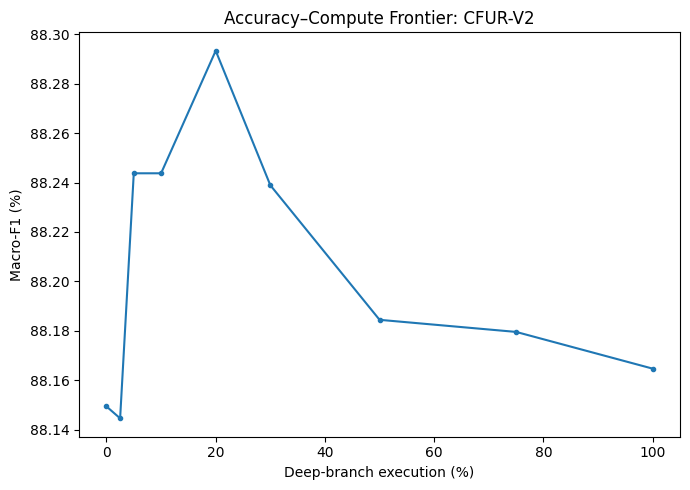

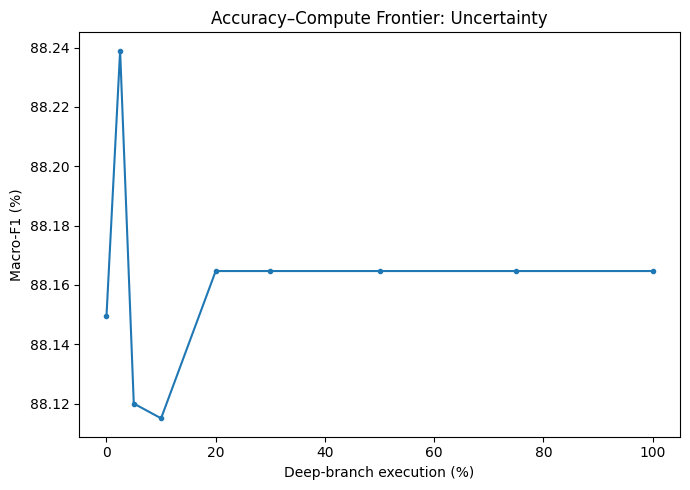

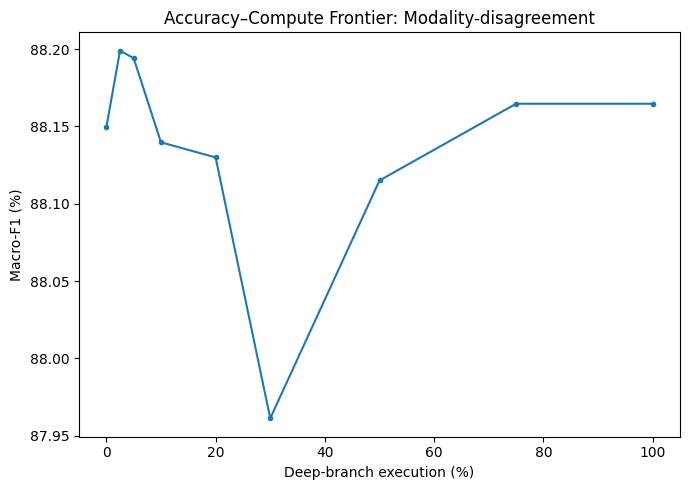

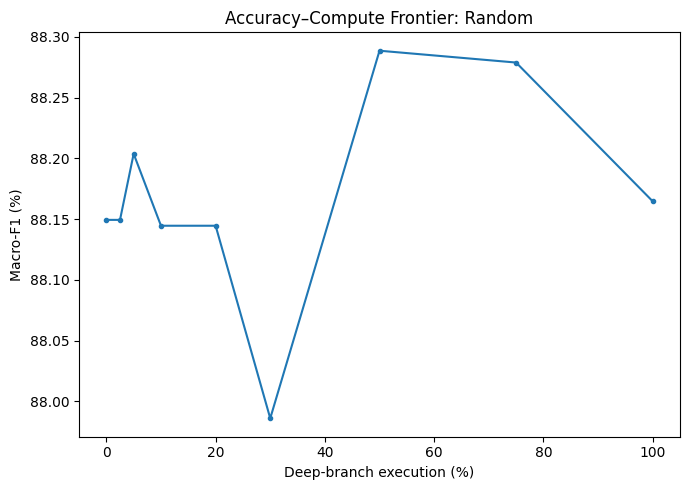

In [62]:
methods=["CFUR-V2","Uncertainty","Modality-disagreement","Random"]

for method in methods:
    g=summary[summary.method==method].sort_values("budget")
    plt.figure(figsize=(7,5))
    plt.plot(
        g["deep_rate_mean"]*100,
        g["macro_f1_mean"]*100,
        marker="."
    )
    plt.xlabel("Deep-branch execution (%)")
    plt.ylabel("Macro-F1 (%)")
    plt.title(f"Accuracy–Compute Frontier: {method}")
    plt.tight_layout()
    plt.savefig(
        OUT_DIR/f"pareto_{method.lower().replace('-','_')}.png",
        dpi=220
    )
    plt.show()

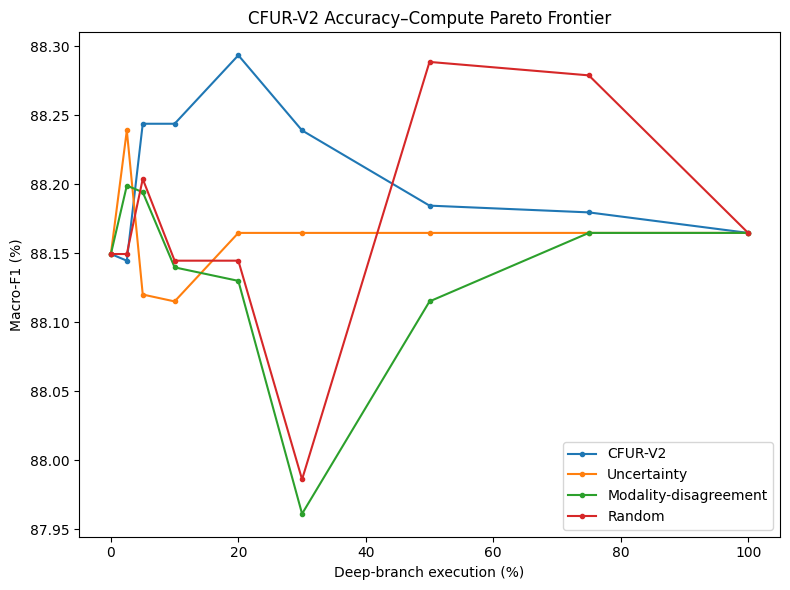

In [63]:
# Combined frontier.
plt.figure(figsize=(8,6))
for method in methods:
    g=summary[summary.method==method].sort_values("budget")
    plt.plot(
        g["deep_rate_mean"]*100,
        g["macro_f1_mean"]*100,
        marker=".",
        label=method
    )
plt.xlabel("Deep-branch execution (%)")
plt.ylabel("Macro-F1 (%)")
plt.title("CFUR-V2 Accuracy–Compute Pareto Frontier")
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR/"v2_combined_pareto.png",dpi=240)
plt.show()

## Statistical test at matched budgets

The important comparisons are **paired** because every method is evaluated on the same test samples and the same deep predictions.

For each budget we compare:

- CFUR-V2 vs. Uncertainty
- CFUR-V2 vs. Modality-disagreement
- CFUR-V2 vs. Random
- CFUR-V2 vs. CLIP-only

The bootstrap reports a 95% CI for the Macro-F1 difference. If the interval crosses zero, the notebook does not claim superiority.

In [64]:
def paired_bootstrap_table(run, budgets=BUDGETS):
    y=run["arrays"]["y"]
    cheap=run["arrays"]["cheap"]
    deep=run["arrays"]["deep"]
    score=run["arrays"]["cfur_score"]

    out=[]
    for budget in budgets:
        cf_route=exact_k_route(score,budget)
        cf=route_logits(cheap,deep,cf_route).argmax(1)

        for base_name,base_score in [
            ("CLIP-cheap",1-softmax_np(cheap).max(1)),
        ]:
            if base_name=="CLIP-cheap":
                base=cheap.argmax(1)

            lo,med,hi=bootstrap_diff(
                y,cf,base,f1_score_macro,N_BOOT,seed=8000+int(budget*1000)
            )
            out.append({
                "seed":run["seed"],
                "budget":budget,
                "comparison":f"CFUR-V2 - {base_name}",
                "ci_low":lo,
                "median_diff":med,
                "ci_high":hi
            })

        # Uncertainty
        ur=exact_k_route(1-softmax_np(cheap).max(1),budget)
        up=route_logits(cheap,deep,ur).argmax(1)
        lo,med,hi=bootstrap_diff(
            y,cf,up,f1_score_macro,N_BOOT,seed=9000+int(budget*1000)
        )
        out.append({
            "seed":run["seed"],"budget":budget,
            "comparison":"CFUR-V2 - Uncertainty",
            "ci_low":lo,"median_diff":med,"ci_high":hi
        })

    return pd.DataFrame(out)

def f1_score_macro(y,p):
    return f1_score(y,p,average="macro")

bootstrap_all=pd.concat(
    [paired_bootstrap_table(r) for r in runs],
    ignore_index=True
)
display(bootstrap_all)
bootstrap_all.to_csv(OUT_DIR/"v2_paired_bootstrap_95ci.csv",index=False)

,seed,budget,comparison,ci_low,median_diff,ci_high
0,13,0.000,CFUR-V2 - CLIP-cheap,0.000000,0.000000,0.000000
1,13,0.000,CFUR-V2 - Uncertainty,0.000000,0.000000,0.000000
2,13,0.025,CFUR-V2 - CLIP-cheap,-0.001171,-0.000046,0.001000
3,13,0.025,CFUR-V2 - Uncertainty,-0.004150,-0.000987,0.002473
4,13,0.050,CFUR-V2 - CLIP-cheap,-0.000692,0.000949,0.002969
5,13,0.050,CFUR-V2 - Uncertainty,-0.002868,0.001197,0.005292
6,13,0.100,CFUR-V2 - CLIP-cheap,-0.000612,0.000971,0.003466
7,13,0.100,CFUR-V2 - Uncertainty,-0.003250,0.001293,0.005915
8,13,0.200,CFUR-V2 - CLIP-cheap,-0.001120,0.001408,0.003973
9,13,0.200,CFUR-V2 - Uncertainty,-0.001969,0.001375,0.004970


## Resource accounting

The effective expected latency is:

`cheap_cost + deep_rate × extra_deep_cost`

This is more informative than reporting the deep branch alone.

In [65]:
test_clip_ms=float(
    resource_components[
        (resource_components.split=="test")&
        (resource_components.component=="CLIP")
    ].ms_per_sample.iloc[0]
)
test_vilt_ms=float(
    resource_components[
        (resource_components.split=="test")&
        (resource_components.component=="ViLT")
    ].ms_per_sample.iloc[0]
)

resource_budget=[]
for budget in BUDGETS:
    effective=test_clip_ms+budget*test_vilt_ms
    savings=1-effective/(test_clip_ms+test_vilt_ms)
    resource_budget.append({
        "budget":budget,
        "clip_ms_per_sample":test_clip_ms,
        "vilt_ms_per_sample":test_vilt_ms,
        "effective_ms_per_sample":effective,
        "latency_reduction_vs_always_deep":savings,
        "relative_extra_compute_fraction":budget
    })

resource_budget=pd.DataFrame(resource_budget)
display(resource_budget)
resource_budget.to_csv(OUT_DIR/"v2_resource_budget_curve.csv",index=False)

,budget,clip_ms_per_sample,vilt_ms_per_sample,effective_ms_per_sample,latency_reduction_vs_always_deep,relative_extra_compute_fraction
0,0.000,9.681962,19.270856,9.681962,0.665595,0.000
1,0.025,9.681962,19.270856,10.163733,0.648955,0.025
2,0.050,9.681962,19.270856,10.645504,0.632315,0.050
3,0.100,9.681962,19.270856,11.609047,0.599036,0.100
4,0.200,9.681962,19.270856,13.536133,0.532476,0.200
5,0.300,9.681962,19.270856,15.463218,0.465917,0.300
6,0.500,9.681962,19.270856,19.317390,0.332798,0.500
7,0.750,9.681962,19.270856,24.135104,0.166399,0.750
8,1.000,9.681962,19.270856,28.952818,0.000000,1.000


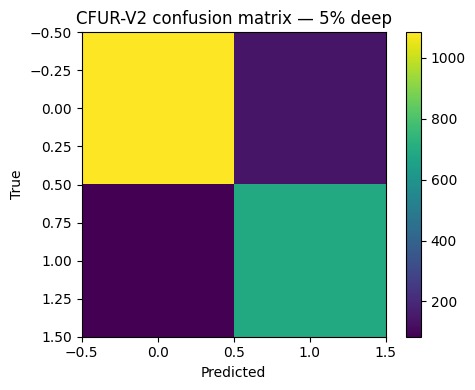

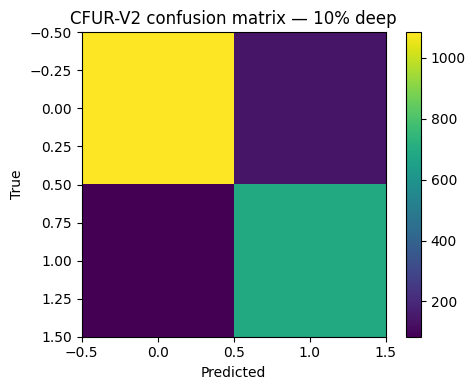

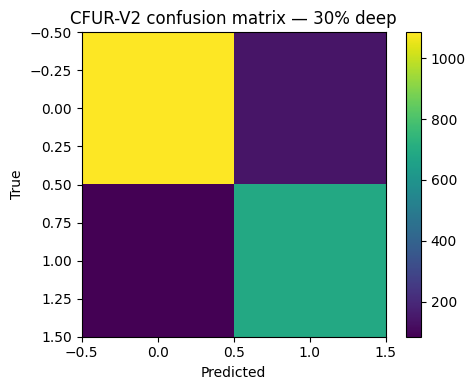

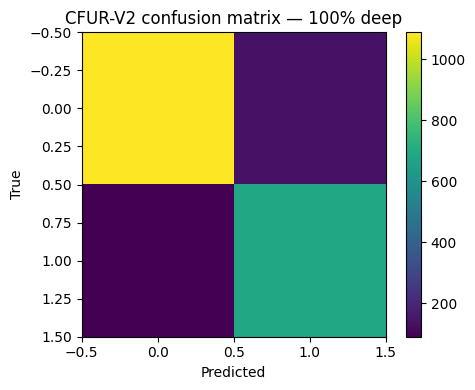

In [66]:
# Confusion matrices for the 10% budget, one representative seed.
rep=runs[0]
y=rep["arrays"]["y"]
cheap=rep["arrays"]["cheap"]
deep=rep["arrays"]["deep"]
score=rep["arrays"]["cfur_score"]

for budget in [0.05,0.10,0.30,1.0]:
    route=exact_k_route(score,budget)
    pred=route_logits(cheap,deep,route).argmax(1)
    cm=confusion_matrix(y,pred)
    pd.DataFrame(cm).to_csv(
        OUT_DIR/f"v2_confusion_matrix_cfur_{int(budget*100)}pct.csv",
        index=False
    )
    plt.figure(figsize=(5,4))
    plt.imshow(cm)
    plt.title(f"CFUR-V2 confusion matrix — {budget:.0%} deep")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.colorbar()
    plt.tight_layout()
    plt.savefig(
        OUT_DIR/f"v2_confusion_matrix_cfur_{int(budget*100)}pct.png",
        dpi=200
    )
    plt.show()

In [67]:
# Parameter counts.
def param_counts(model):
    return {
        "total":sum(p.numel() for p in model.parameters()),
        "trainable":sum(p.numel() for p in model.parameters() if p.requires_grad)
    }

rep=runs[0]
params=pd.DataFrame([
    {"component":"CLIP backbone",**param_counts(clip_model)},
    {"component":"ViLT backbone",**param_counts(vilt_model)},
    {"component":"Cheap head",**param_counts(rep["cheap"])},
    {"component":"Deep residual head",**param_counts(rep["deep"])},
    {"component":"Text head",**param_counts(rep["text_head"])},
    {"component":"Image head",**param_counts(rep["image_head"])},
    {"component":"Utility router",**param_counts(rep["router"])}
])
display(params)
params.to_csv(OUT_DIR/"v2_parameter_counts.csv",index=False)

,component,total,trainable
0,CLIP backbone,151277313,0
1,ViLT backbone,111595008,0
2,Cheap head,558466,558466
3,Deep residual head,1118466,1118466
4,Text head,164994,164994
5,Image head,164994,164994
6,Utility router,542849,542849


# Decision gate

V2 should be considered a **successful method experiment** only if the final multi-seed results show a consistent advantage of CFUR-V2 over the matched-cost uncertainty and modality-disagreement baselines on a meaningful part of the budget curve.

If CFUR-V2 does not beat those baselines, do **not** manufacture a novelty claim. The correct conclusion is that confidence/disagreement routing is a stronger and simpler solution for this benchmark, and the method should be redesigned before submission.

For the manuscript run:

```python
RUN_MODE = "PAPER"
TASKS_TO_RUN = ["binary"]
FAKEDDIT_LABEL_COL = "2_way_label"
```

then rerun with a local-image manifest.

For the fine-grained experiment:

```python
FAKEDDIT_LABEL_COL = "6_way_label"
```

and rerun from the data-loading cell.

### Files generated

- `v2_all_seed_budget_metrics.csv`
- `v2_manuscript_summary_mean_sd.csv`
- `v2_validation_budget_metrics.csv`
- `v2_paired_bootstrap_95ci.csv`
- `v2_resource_budget_curve.csv`
- `v2_parameter_counts.csv`
- `v2_test_predictions.csv`
- `v2_combined_pareto.png`
- per-method Pareto figures
- budget-specific confusion matrices

Do not report any performance number in the paper until the PAPER-mode run is complete.